# Librerias

In [117]:
import pandas as pd
import numpy as np
import optuna
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import log_loss, roc_auc_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, shapiro, normaltest

# Carga de datos

In [118]:
# Carga de datos
train = pd.read_csv('/kaggle/input/playground-series-s5e12/train.csv')
test = pd.read_csv('/kaggle/input/playground-series-s5e12/test.csv')

# Separación de features y target
X = train.drop(['id', 'diagnosed_diabetes'], axis=1)
y = train['diagnosed_diabetes']
test_fe = test.drop(['id'], axis=1)

# Análisis del Dataset
---

El dataset cuenta con 700.000 observaciones y 24 features, distribuidas en 13 enteras, 6 categóricas y 5 continuas. No hay valores nulos, por lo que no es necesario realizar imputaciones, reduciendo así una posible fuente de ruido en el modelo. 

El análisis del skewness y kurtosis muestra que existen variables con valores enteros con alta asimetría y curtosis elevada como `hypertension_history` o `cardiovascular_history`. Se puede ver en los histogramas que se tratan de variables binarias o discretas.

Dado que el dataset incluye tanto variables categóricas explícitas (por ejemplo, gender, ethnicity, education_level) como variables discretas que pueden beneficiarse de un tratamiento categórico, se opta por CatBoost como modelo.

Además, aunque algunas variables numéricas presentan asimetría o colas pesadas (por ejemplo, `physical_activity_minutes_per_week`), no se aplican transformaciones distribucionales, ya que los modelos basados en árboles de decisión son inherentemente robustos frente a distribuciones no gaussianas.

### Funciones

In [119]:
def describe_dataset(df: pd.DataFrame):
    
    print("--- Shape ---")
    
    # shape
    num_rows, num_cols = df.shape
    print(f"({num_rows:,}, {num_cols:,})")
    
    print("\n--- Tipos de datos ---")
    
    # data types
    dtype_counts = df.dtypes.astype(str).value_counts().reset_index()
    dtype_counts.columns = ['Data_Type', 'Count']
    print(dtype_counts.to_markdown(index=False))

def analyze_numeric_distribution(df, variables=None, sample_size=300000):
    
    if variables is None:
        variables = df.select_dtypes(include=[np.number]).columns.tolist()
    
    insights = []

    for col in variables:
        data = df[col].dropna()

        # Safety sample for Shapiro test
        sample = data.sample(min(len(data), sample_size), random_state=42)

        # Compute statistics
        col_skew = skew(data)
        col_kurt = kurtosis(data)

        # Plot distribution
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        sns.histplot(data, kde=True, bins=30, color="steelblue")
        plt.title(f"Distribution of {col}")

        plt.tight_layout()
        plt.show()
        
        insights.append({
            "variable": col,
            "skewness": col_skew,
            "kurtosis": col_kurt,
        })

    return pd.DataFrame(insights)

def plot_categorical_distribution(df, column, top_n=15, figsize=(10, 5)):
    """
    Plots the percentage distribution of a categorical variable.
    
    Parameters:
        df      : DataFrame
        column  : str, categorical column to plot
        top_n   : int, number of most frequent categories to display
        figsize : tuple, size of the plot
    """

    # Drop missing values
    data = df[column].dropna()

    # Value counts normalized (percentage)
    perc = (data.value_counts(normalize=True) * 100).sort_values(ascending=False)

    # Restrict to top_n categories (to avoid clutter)
    if len(perc) > top_n:
        perc = perc.head(top_n)

    plt.figure(figsize=figsize)
    ax = sns.barplot(x=perc.index, y=perc.values, palette="viridis")

    # Add percentages above bars
    for i, v in enumerate(perc.values):
        ax.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=10)

    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Percentage (%)")
    plt.title(f"Percentage Distribution of '{column}'")
    plt.tight_layout()
    plt.show()


### Tipos de datos y valores nulos

In [120]:
describe_dataset(X)

missing_counts = X.isnull().sum()
print("\n--- Valores nulos ---")
print(missing_counts)


--- Shape ---
(700,000, 24)

--- Tipos de datos ---
| Data_Type   |   Count |
|:------------|--------:|
| int64       |      13 |
| object      |       6 |
| float64     |       5 |

--- Valores nulos ---
age                                   0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
smoking_status                     

### Histogramas, skewness y curtosis

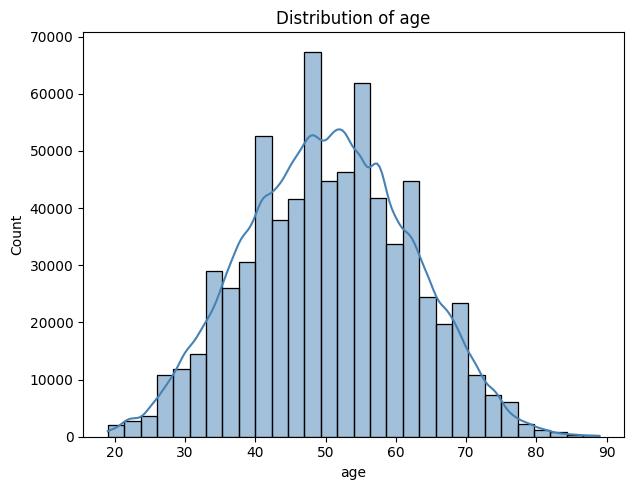

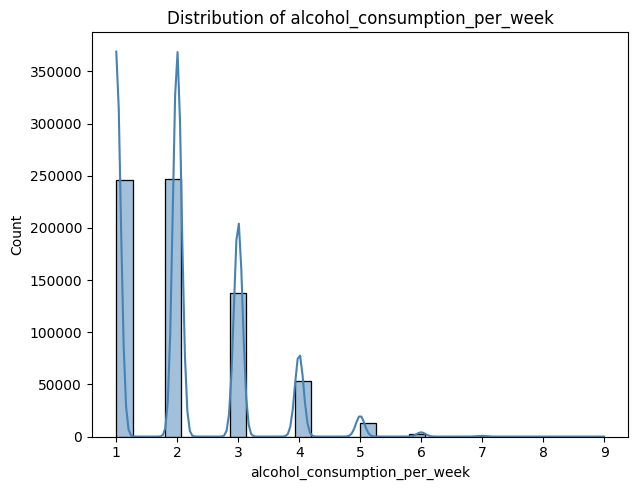

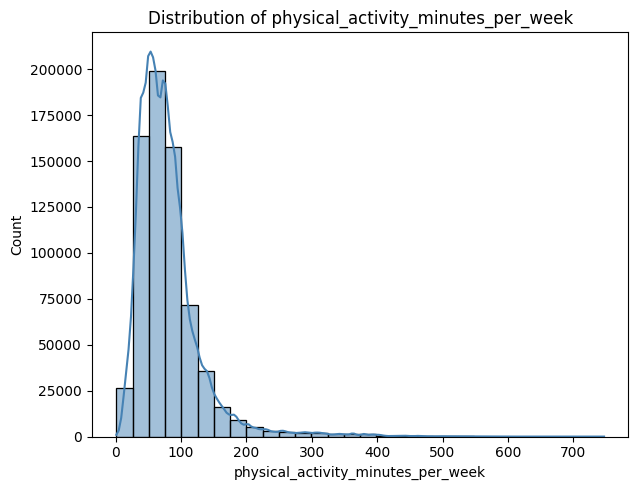

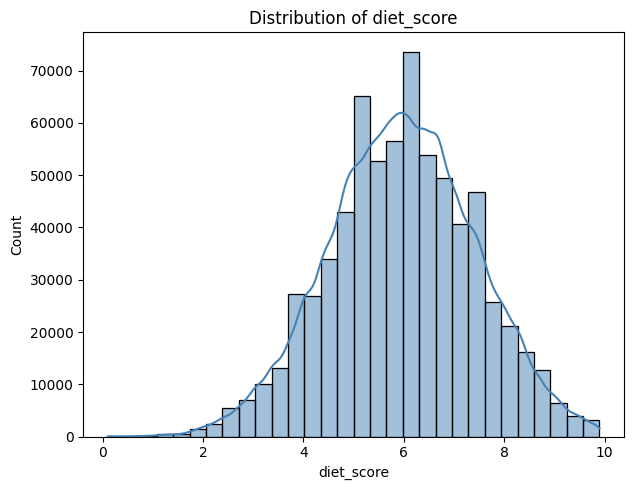

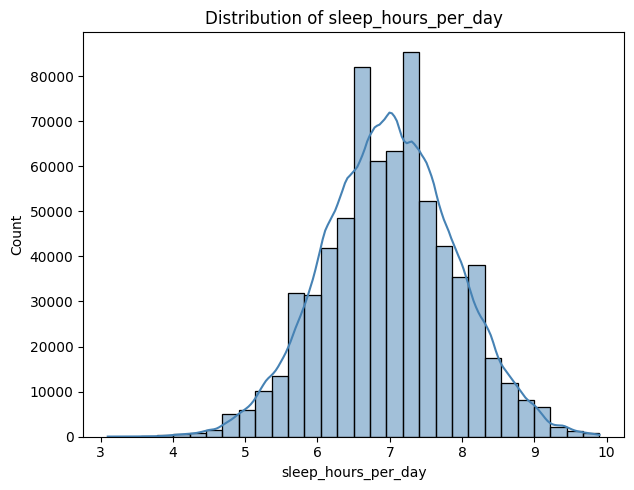

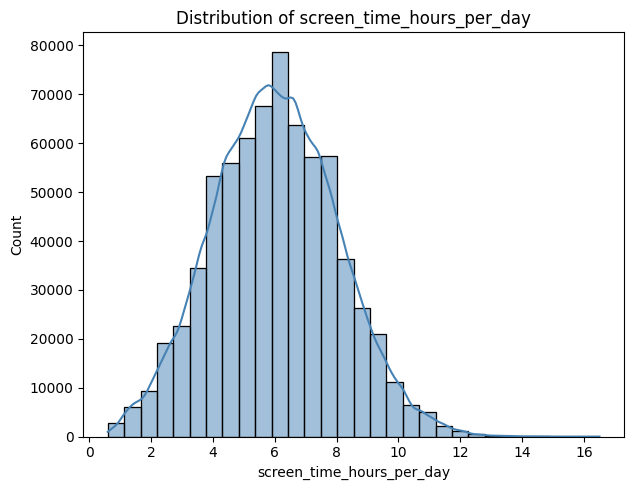

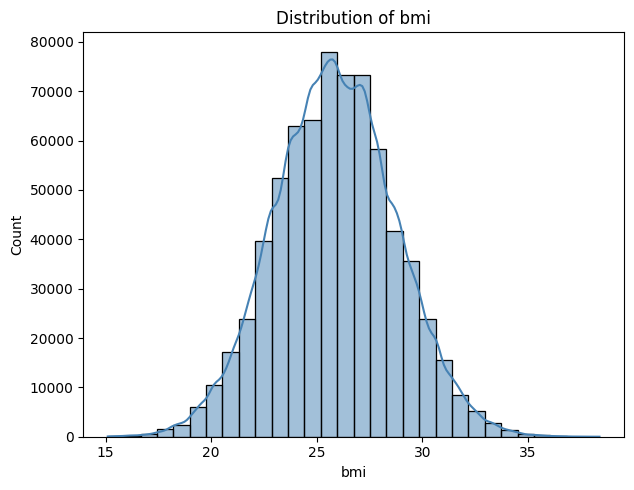

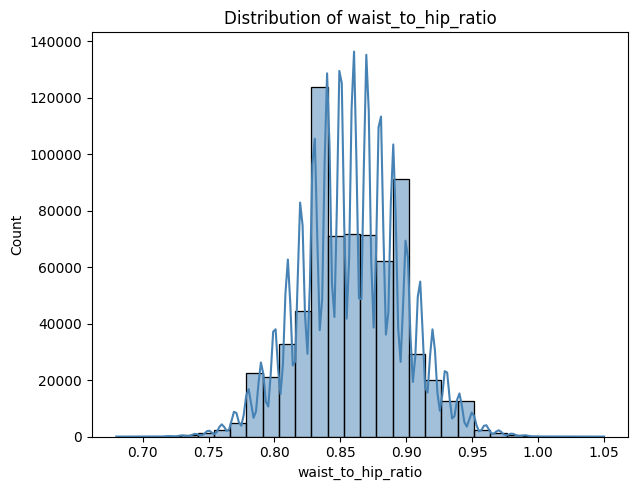

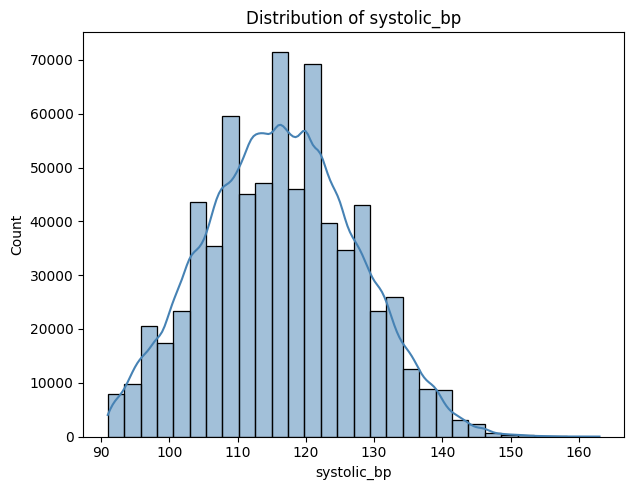

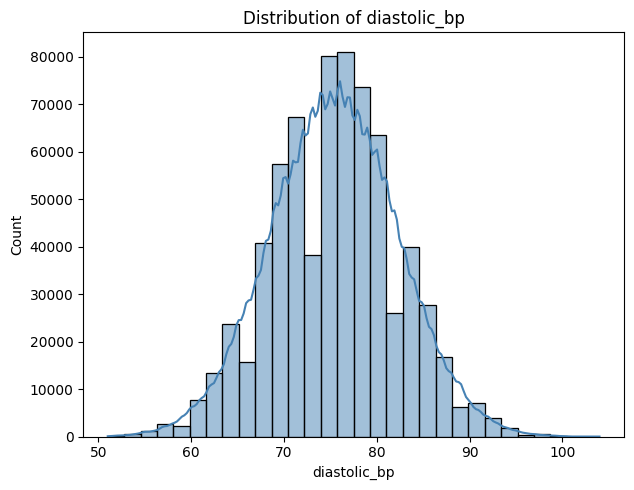

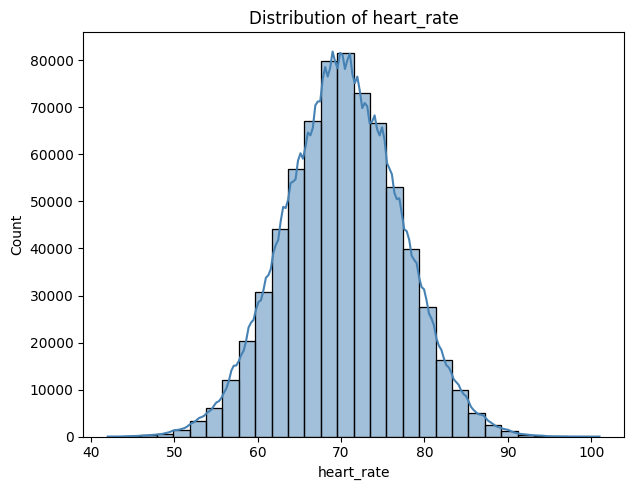

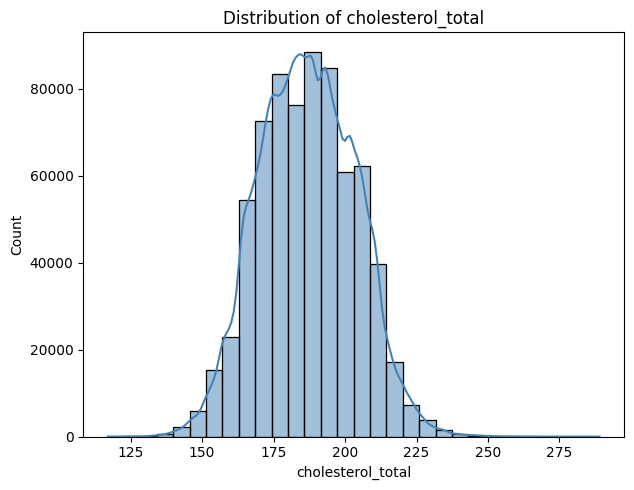

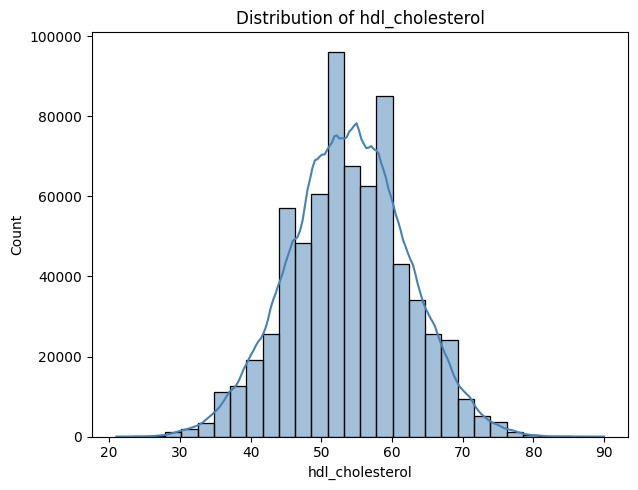

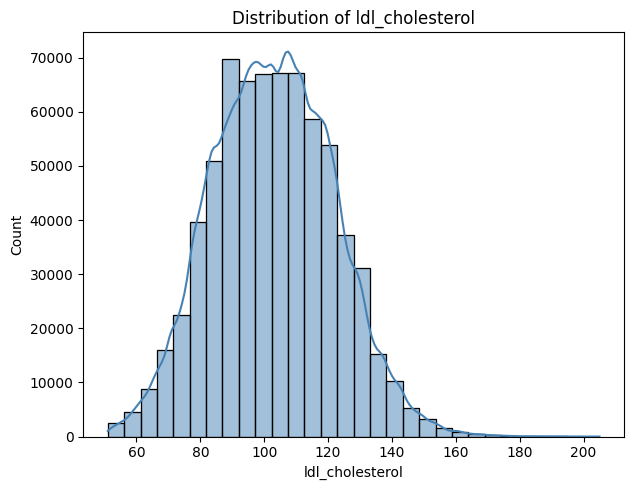

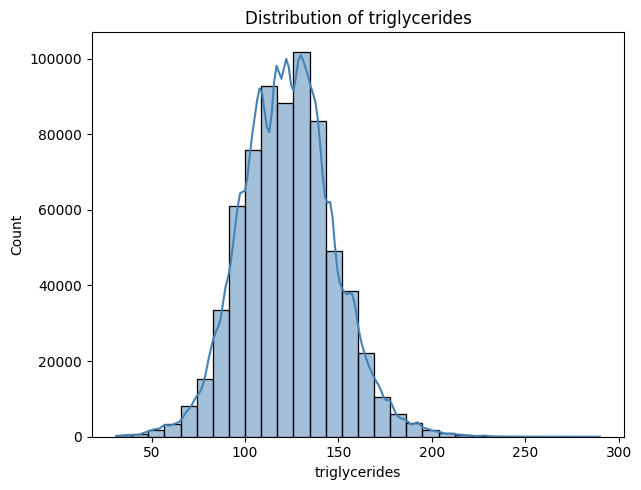

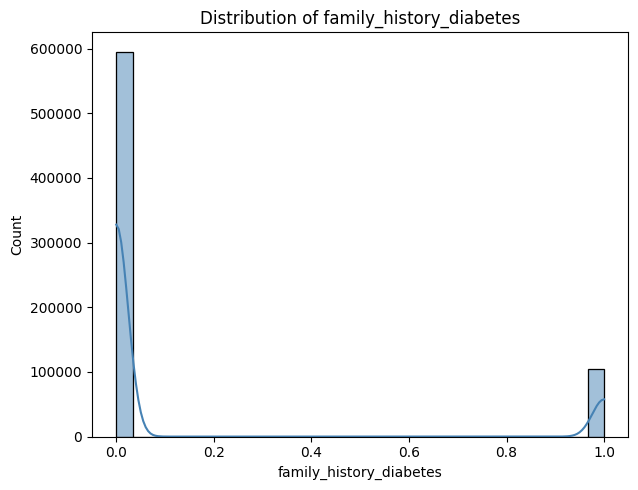

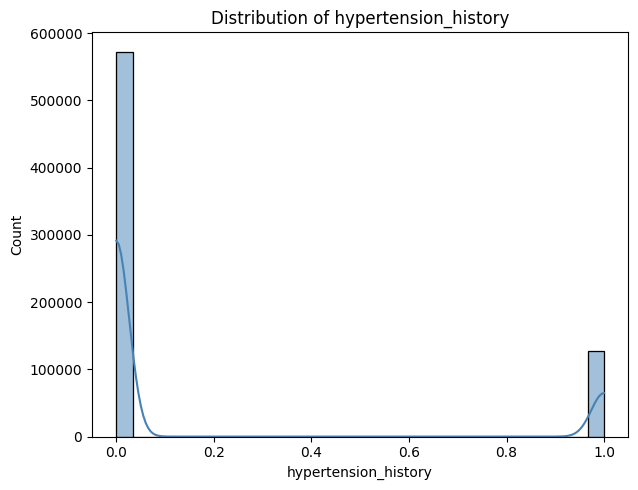

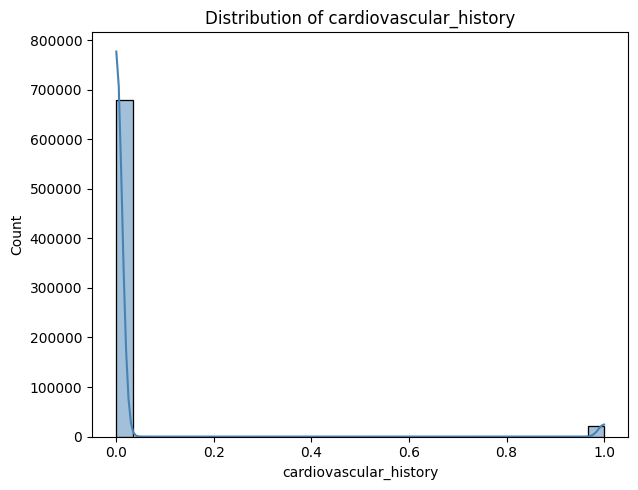

,variable,skewness,kurtosis
0,age,0.020905,-0.386746
1,alcohol_consumption_per_week,0.932373,0.704165
2,physical_activity_minutes_per_week,2.814191,13.196969
3,diet_score,-0.062970,-0.161260
4,sleep_hours_per_day,0.001486,-0.059958
5,screen_time_hours_per_day,0.114109,-0.132795
6,bmi,0.032107,-0.022292
7,waist_to_hip_ratio,0.037715,0.011089
8,systolic_bp,0.097208,-0.393853
9,diastolic_bp,-0.001377,-0.037283


In [121]:
analyze_numeric_distribution(X)

/tmp/ipykernel_55/3273116655.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=perc.index, y=perc.values, palette="viridis")


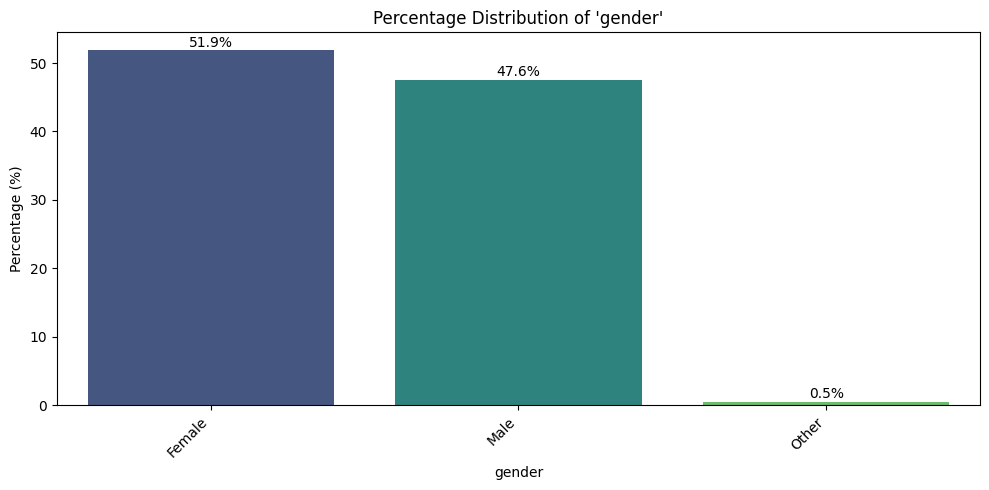

/tmp/ipykernel_55/3273116655.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=perc.index, y=perc.values, palette="viridis")


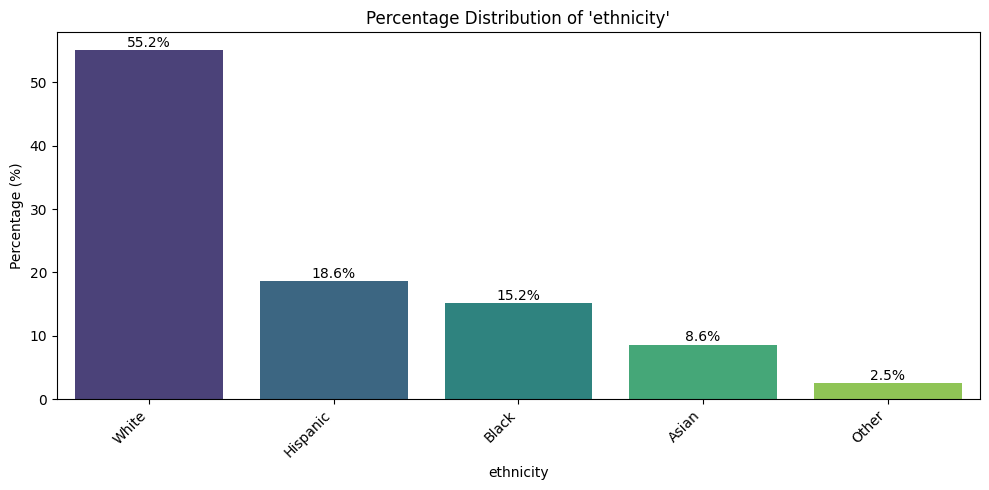

/tmp/ipykernel_55/3273116655.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=perc.index, y=perc.values, palette="viridis")


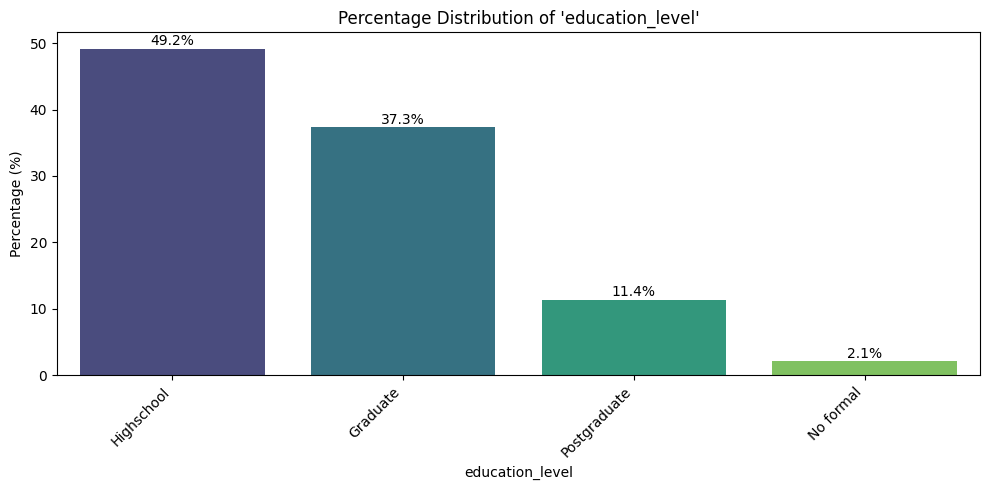

/tmp/ipykernel_55/3273116655.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=perc.index, y=perc.values, palette="viridis")


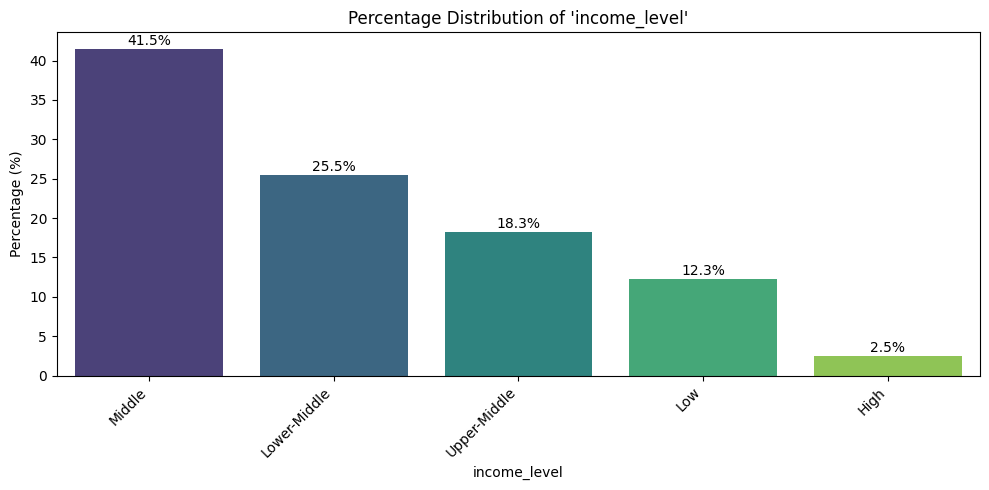

/tmp/ipykernel_55/3273116655.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=perc.index, y=perc.values, palette="viridis")


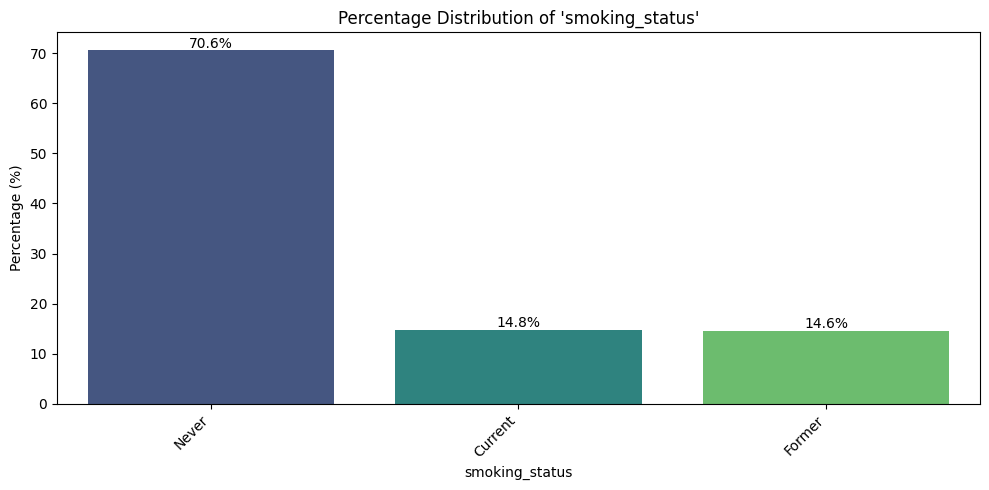

/tmp/ipykernel_55/3273116655.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=perc.index, y=perc.values, palette="viridis")


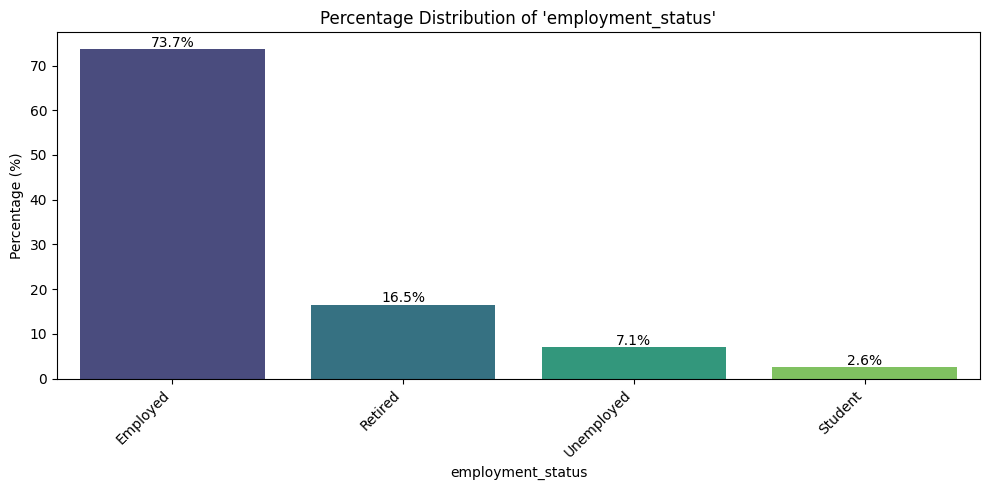

In [122]:

cat_cols = train.select_dtypes(include=['object']).columns.tolist()

for col in cat_cols:
    plot_categorical_distribution(X, col)

# Adversarial Validation
---
En las competiciones de Kaggle no se garantiza que los conjuntos de train y test se extraigan de la misma distribución de datos. Pequeñas diferencias pueden invalidar los resultados, obteniendo resultados buenos en estimaciones, pero una generalización mala en la clasificación privada.

Para evaluar esto, se realiza un Adversarial Validation.

**Metodologia**

Se construye un problema de clasificación binaria para determinar si una observación viene del conjunto de train o del conjunto de test

- `is_test` = 0 => La observación viene del conjunto de train
- `is_test` = 1 => La observación viene del conjunto de test

Solo se utilizan features comunes a ambos conjuntos excluyendo explícitamente `id` y `diagnosed_diabetes` para evitar data leakage.

Para la clasificación se utiliza un XGBoost Classifier utilizando StratifiedKFold, que divide el dataset en K folds. Luego se entrena el modelo con K-1 folds y se valida con el fold restante, lo que permite preservar la proporción de clases en cada fold y obtener una estimación estable del rendimiento 

**Resultados**

El ROC-AUC es cercano a 0.6, indicando que el clasificador es incapaz de distinguir entre observaciones del conjunto de test y del conjunto de train.

El riesgo de sobreajuste debido a diferentes distribuciones en los conjuntos de test y train es bajo.

In [123]:
cat_cols = train.select_dtypes(include=['object']).columns.tolist()

def prepare_adversarial_data_final(df_train, df_test):
    # 1. Definir features comunes (excluyendo ID y Target)
    target = 'diagnosed_diabetes'
    common_cols = [c for c in df_train.columns if c in df_test.columns and c not in ['id', target]]
    
    # 2. Extraer solo esas columnas
    X_tr = df_train[common_cols].copy()
    X_te = df_test[common_cols].copy()
    
    # 3. Marcamos origen
    X_tr['is_test'] = 0
    X_te['is_test'] = 1
    
    combined = pd.concat([X_tr, X_te], axis=0).reset_index(drop=True)
    
    # 4. Encoding
    le = LabelEncoder()
    cat_features = combined.select_dtypes(include=['object']).columns
    for col in cat_features:
        combined[col] = le.fit_transform(combined[col].astype(str))
        
    return combined.drop('is_test', axis=1), combined['is_test']

# Ejecuta y verifica
X_adv, y_adv = prepare_adversarial_data_final(train, test)

# 3. Ejecución del Adversarial Validation
model_adv = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    tree_method='hist' # Más rápido para auditoría
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_scores = cross_val_score(model_adv, X_adv, y_adv, cv=cv, scoring='roc_auc')

print(f"--- RESULTADOS  ---")
print(f"Adversarial AUC: {auc_scores.mean():.4f} (+/- {auc_scores.std():.4f})")

# 4. Identificación de variables problemáticas 
model_adv.fit(X_adv, y_adv)
importances = pd.DataFrame({
    'feature': X_adv.columns,
    'importance': model_adv.feature_importances_
}).sort_values(by='importance', ascending=False)

print("\nTop 10 Variables que diferencian Train de Test:")
print(importances.head(10))

--- RESULTADOS  ---
Adversarial AUC: 0.6215 (+/- 0.0018)

Top 10 Variables que diferencian Train de Test:
                               feature  importance
2   physical_activity_minutes_per_week    0.281138
14                       triglycerides    0.112880
10                          heart_rate    0.102630
11                   cholesterol_total    0.073812
6                                  bmi    0.071695
17                     education_level    0.057717
7                   waist_to_hip_ratio    0.041837
13                     ldl_cholesterol    0.029807
16                           ethnicity    0.026089
21             family_history_diabetes    0.025120


# Featuree Engeenering
---
### Feature: waist_to_bmi_ratio

El índice de masa corporal (`BMI`) mide el peso en relación con la altura, pero no indica dónde se acumula la grasa. La evidencia médica muestra que la grasa acumulada en la zona abdominal (grasa visceral) está más relacionada con el desarrollo de diabetes tipo 2 que el peso total.

Esta variable combina una medida de obesidad central con el BMI para capturar mejor el riesgo metabólico asociado a la distribución de la grasa corporal.

Referencia:
https://pubmed.ncbi.nlm.nih.gov/16278693/

### Feature: Metabolic Stress Index: (diet_score * bmi) / physical_activity_minutes_per_week

La diabetes tipo 2 está relacionada con un desequilibrio entre la energía que entra al cuerpo y la que se gasta.

Este índice combina:

- La carga dietética (`diet_score`)

- El tamaño corporal (`BMI`)

- El nivel de actividad física (`physical_activity`)

Valores altos indican mucho consumo energético y poco gasto, una combinación asociada con mayor riesgo de resistencia a la insulina.

Referencia:
https://www.ncbi.nlm.nih.gov/books/NBK278936/

### Feature: Sleep Efficiency Proxy: sleep_hours_per_day - (screen_time_hours_per_day * 0.5)

El sueño juega un papel importante en la regulación del azúcar en sangre. Dormir poco o tener una mala calidad de sueño puede afectar negativamente al metabolismo de la glucosa.

Esta variable ajusta las horas de sueño penalizando el tiempo de pantalla, ya que el uso de dispositivos electrónicos puede interferir con el descanso nocturno. De esta forma, se aproxima la calidad efectiva del sueño.

Referencia:
https://ec.bioscientifica.com/view/journals/ec/12/11/EC-23-0064.xml

### Feature: Lipid Ratio: triglycerides / hdl_cholesterol

El ratio entre triglicéridos y colesterol HDL es un marcador ampliamente utilizado de riesgo metabólico.

Un valor elevado suele indicar un perfil asociado con resistencia a la insulina y mayor probabilidad de desarrollar diabetes tipo 2, incluso cuando otros indicadores parecen normales.

Referencia:
https://pmc.ncbi.nlm.nih.gov/articles/PMC8653431

### Feature: Mean Arterial Pressure (MAP): (2*diastolic_bp + systolic_bp) / 3

La hipertensión y la diabetes suelen aparecer juntas como parte del síndrome metabólico.

El MAP resume la presión arterial promedio que soportan los vasos sanguíneos y puede reflejar un riesgo cardiovascular sostenido, que está estrechamente relacionado con alteraciones metabólicas.

Referencia:
https://www.nature.com/articles/hr201572

### Feature: activity_per_bmi: physical_activity_minutes_per_week / bmi

Esta variable mide la eficiencia relativa de la actividad física en función del tamaño corporal.

Un BMI elevado no tiene el mismo significado clínico en una persona físicamente activa que en una persona sedentaria.

### Feature: age_family_risk: age * family_history_diabetes

La predisposición genética a la diabetes tipo 2 no es un factor estático: su impacto aumenta con la edad.

De esta forma, el modelo puede aprender que un antecedente familiar tiene un peso distinto en individuos jóvenes que en adultos mayores.

### Feature: is_high_risk_metabolic: (tg_hdl_ratio > 3.0) & (bmi > 30)

Esta variable binaria define un perfil clínico de alto riesgo metabólico, basado en umbrales comúnmente utilizados en la práctica médica:

- Ratio triglicéridos/HDL > 3.0 -> marcador de resistencia a la insulina

- BMI > 30 -> obesidad

La combinación de ambos criterios identifica un subgrupo de pacientes con un riesgo particularmente elevado de diabetes tipo 2

### Implemetación de Ordinal Mapping

CatBoost trata a `education_level` e `income_level` como categorías puras. Pero para la diabetes, el gradiente socioeconómico es un factor de riesgo lineal documentado por la OMS.

Este enfoque permite al modelo capturar relaciones monótonas entre nivel socioeconómico y riesgo de diabetes.

```python
edu_map = {'Highschool': 1, 'Associate Degree': 2, 'Bachelor': 3, 'Master': 4, 'PhD': 5}
inc_map = {'Lower': 1, 'Lower-Middle': 2, 'Middle': 3, 'Upper-Middle': 4, 'Upper': 5}
```

### Features: Señales médicas
Se crean variables indicadoras basadas en los puntos de corte oficiales de salud.

In [124]:
def apply_feature_engineering(df):
    df = df.copy()
    
    df['waist_to_bmi_ratio'] = df['waist_to_hip_ratio'] / (df['bmi'] + 1e-6)
    df['metabolic_stress'] = (df['diet_score'] * df['bmi']) / (df['physical_activity_minutes_per_week'] + 1)
    df['sleep_efficiency'] = df['sleep_hours_per_day'] - (df['screen_time_hours_per_day'] * 0.5)
    df['tg_hdl_ratio'] = df['triglycerides'] / (df['hdl_cholesterol'] + 1e-6)
    df['mean_arterial_pressure'] = (2 * df['diastolic_bp'] + df['systolic_bp']) / 3
    
    return df

def apply_ordinal_mapping(df):
    df = df.copy()
    
    # Definir jerarquías lógicas
    edu_map = {'Highschool': 1, 'Associate Degree': 2, 'Bachelor': 3, 'Master': 4, 'PhD': 5}
    inc_map = {'Lower': 1, 'Lower-Middle': 2, 'Middle': 3, 'Upper-Middle': 4, 'Upper': 5}
    
    df['education_level'] = df['education_level'].map(edu_map).fillna(0)
    df['income_level'] = df['income_level'].map(inc_map).fillna(0)
    
    return df

def apply_advanced_interactions(df):
    df = df.copy()

    df['activity_per_bmi'] = df['physical_activity_minutes_per_week'] / (df['bmi'] + 1e-6)
    df['age_family_risk'] = df['age'] * df['family_history_diabetes']
    df['is_high_risk_metabolic'] = ((df['tg_hdl_ratio'] > 3.0) & (df['bmi'] > 30)).astype(int)
    
    return df

def apply_medic_signals(df):
    df = df.copy()
    
    df['high_triglycerides'] = (df['triglycerides'] > 150).astype(int)
    df['hypertension_stage2'] = (df['systolic_bp'] > 140).astype(int)
    df['is_over_45'] = (df['age'] > 45).astype(int)

    df['is_obese'] = (df['bmi'] >= 30).astype(int)
    df['is_prehypertensive'] = (df['systolic_bp'] >= 130).astype(int)
    df['is_high_tg'] = (df['triglycerides'] >= 150).astype(int)
    
    # Una variable que combine los 3 grandes riesgos (Metabolic Syndrome Flag)
    df['metabolic_syndrome_score'] = df['is_obese'] + df['is_prehypertensive'] + df['is_high_tg']
    
    return df

# Entrenamiento del modelo
---

In [125]:
X = apply_feature_engineering(X)
X = apply_ordinal_mapping(X)
X = apply_advanced_interactions(X)
X = apply_medic_signals(X)

test_fe = apply_feature_engineering(test_fe)
test_fe = apply_ordinal_mapping(test_fe)
test_fe = apply_advanced_interactions(test_fe)
test_fe = apply_medic_signals(test_fe)

In [126]:
# Definir variables
cat_features = X.select_dtypes(include=['object']).columns.tolist()

# Pipeline de validación
kf = RepeatedStratifiedKFold(n_splits=5, n_repeats=1, random_state=42)
oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(test_fe))

# Inicializamos una lista para guardar las importancias de cada fold
all_importances = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = CatBoostClassifier(
        iterations=2000,           
        learning_rate=0.04,        
        depth=8,                   
        l2_leaf_reg=5,             
        random_strength=1,         
        loss_function='Logloss',
        eval_metric='AUC',
        cat_features=cat_features,
        early_stopping_rounds=100,
        verbose=200
    )
    
    model.fit(X_train, y_train, eval_set=(X_val, y_val), use_best_model=True)

    # Guardamos importancia de este fold
    all_importances.append(model.get_feature_importance())
    
    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
    test_preds += model.predict_proba(test_fe)[:, 1] / 5

# Calculamos el promedio de importancia de todos los folds
avg_importance = np.mean(all_importances, axis=0)

importances = pd.DataFrame({
    'feature': X.columns,
    'importance': avg_importance
}).sort_values(by='importance', ascending=False)

print("\n--- TOP 15 FEATURES (AVERAGED) ---")
print(importances.head(15))
print(f"\nOverall OOF AUC: {roc_auc_score(y, oof_preds):.5f}")

0:	test: 0.6836150	best: 0.6836150 (0)	total: 691ms	remaining: 23m 2s
200:	test: 0.7108770	best: 0.7108770 (200)	total: 1m 47s	remaining: 16m
400:	test: 0.7182104	best: 0.7182104 (400)	total: 3m 32s	remaining: 14m 5s
600:	test: 0.7226022	best: 0.7226022 (600)	total: 5m 17s	remaining: 12m 19s
800:	test: 0.7241458	best: 0.7241493 (798)	total: 7m 4s	remaining: 10m 35s
1000:	test: 0.7251251	best: 0.7251251 (1000)	total: 8m 53s	remaining: 8m 52s
1200:	test: 0.7256466	best: 0.7256483 (1181)	total: 10m 41s	remaining: 7m 6s
1400:	test: 0.7260694	best: 0.7260694 (1400)	total: 12m 26s	remaining: 5m 19s
1600:	test: 0.7263275	best: 0.7263277 (1599)	total: 14m 12s	remaining: 3m 32s
1800:	test: 0.7265435	best: 0.7265517 (1757)	total: 15m 58s	remaining: 1m 45s
1999:	test: 0.7267335	best: 0.7267335 (1999)	total: 17m 45s	remaining: 0us

bestTest = 0.7267335492
bestIteration = 1999

0:	test: 0.6824835	best: 0.6824835 (0)	total: 656ms	remaining: 21m 51s
200:	test: 0.7092544	best: 0.7092544 (200)	total: 1

In [127]:
submission = pd.DataFrame({
    "id": test["id"],
    "diagnosed_diabetes": test_preds
})

submission.to_csv("submission.csv", index=False)
submission.head(5)

,id,diagnosed_diabetes
0,700000,0.501469
1,700001,0.680183
2,700002,0.778214
3,700003,0.417124
4,700004,0.921739


# Resultados

### 🔹 Modelo Baseline
---
Para establecer una referencia sólida, se entrenó un modelo base utilizando **CatBoostClassifier**, evaluado mediante **Repeated Stratified K-Fold Cross-Validation** con 5 particiones y una repetición, garantizando estabilidad y preservando la proporción de clases en cada fold.

**Esquema de validación**

```python
RepeatedStratifiedKFold(n_splits=5, n_repeats=1, random_state=42)
```
**Configuración del modelo**
```python
CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    cat_features=cat_features,
    early_stopping_rounds=50,
    random_seed=42,
    verbose=100
)
```

**Resultados en Kaggle**

- Public Score: `0.69546`
- Private Score: `0.69122`

### 🔹 5 nuevas features
---
Se añadieron 5 nuevas features investigando que caracteristicas estan relacionadas con la diabetes

```python
df['waist_to_bmi_ratio'] = df['waist_to_hip_ratio'] / (df['bmi'] + 1e-6)
df['metabolic_stress'] = (df['diet_score'] * df['bmi']) / (df['physical_activity_minutes_per_week'] + 1)
df['sleep_efficiency'] = df['sleep_hours_per_day'] - (df['screen_time_hours_per_day'] * 0.5)
df['tg_hdl_ratio'] = df['triglycerides'] / (df['hdl_cholesterol'] + 1e-6)
df['mean_arterial_pressure'] = (2 * df['diastolic_bp'] + df['systolic_bp']) / 3
```

**Esquema de validación**

```python
RepeatedStratifiedKFold(n_splits=5, n_repeats=1, random_state=42)
```
**Configuración del modelo**
```python
CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    cat_features=cat_features,
    early_stopping_rounds=50,
    random_seed=42,
    verbose=100
)
```

**Resultados en Kaggle**

- Public Score: `0.69671`
- Private Score: `0.69297`

El rendimiento subió considerablemente.

### 🔹 Implementación de Ordinal Mapping
---
CatBoost trata a education_level e income_level como categorías puras (como colores). Pero para la diabetes, el gradiente socioeconómico es un factor de riesgo lineal documentado por la OMS.

```python
edu_map = {'Highschool': 1, 'Associate Degree': 2, 'Bachelor': 3, 'Master': 4, 'PhD': 5}
inc_map = {'Lower': 1, 'Lower-Middle': 2, 'Middle': 3, 'Upper-Middle': 4, 'Upper': 5}
    
df['education_level'] = df['education_level'].map(edu_map).fillna(0)
df['income_level'] = df['income_level'].map(inc_map).fillna(0)
```

**Esquema de validación**

```python
RepeatedStratifiedKFold(n_splits=5, n_repeats=1, random_state=42)
```
**Configuración del modelo**
```python
CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    cat_features=cat_features,
    early_stopping_rounds=50,
    random_seed=42,
    verbose=100
)
```

**Resultados en Kaggle**

- Public Score: `0.69690`
- Private Score: `0.69300`

Rendimiento prácticamente igual.

Se analizó la importancia de las features y se obtuvieron los siguientes resultados:

```
--- TOP 15 FEATURES (AVERAGED) ---
                               feature  importance
2   physical_activity_minutes_per_week   33.931920
21             family_history_diabetes   31.840084
0                                  age   11.613164
14                       triglycerides    5.418837
6                                  bmi    2.148546
27                        tg_hdl_ratio    2.134970
13                     ldl_cholesterol    1.784080
11                   cholesterol_total    1.484251
10                          heart_rate    1.283833
3                           diet_score    1.208207
8                          systolic_bp    1.149211
7                   waist_to_hip_ratio    0.989794
24                  waist_to_bmi_ratio    0.776804
5            screen_time_hours_per_day    0.700582
12                     hdl_cholesterol    0.602453
```

- Solo dos variables, `physical_activity_minutes_per_week` y `family_history_diabetes`, dictan casi dos tercios de las predicciones

- Importancia de nuevas Features: `tg_hdl_ratio` esta top 6, superando a variables originales como diet_score o cholesterol_total. `waist_to_bmi_ratio` está top 13, pero las otras features, y las categóricas ordinales `income_level` y `education_level` no aparecen.


### 🔹 3 nuevas features y entrenamiento más agresivo
---
Como la actividad física y el historial genético son tan importantes, con estás nuevas features se estudia como escala con el peso y la edad

```python
df['activity_per_bmi'] = df['physical_activity_minutes_per_week'] / (df['bmi'] + 1e-6)
df['age_family_risk'] = df['age'] * df['family_history_diabetes']
df['is_high_risk_metabolic'] = ((df['tg_hdl_ratio'] > 3.0) & (df['bmi'] > 30)).astype(int)
```

**Esquema de validación**

```python
RepeatedStratifiedKFold(n_splits=5, n_repeats=1, random_state=42)
```
**Configuración del modelo**
```python
CatBoostClassifier(
    iterations=2000,           # Más iteraciones con Early Stopping
    learning_rate=0.03,        # Bajamos el ritmo para una mejor generalización
    depth=8,                   # Aumentamos la profundidad para capturar interacciones
    l2_leaf_reg=5,             # Regularización para evitar que 'activity' domine demasiado
    random_strength=1,         # Añade un poco de aleatoriedad en la selección de splits
    loss_function='Logloss',
    eval_metric='AUC',
    cat_features=cat_features,
    early_stopping_rounds=100,
    verbose=200
)
```

**Resultados en Kaggle**

- Public Score: `0.69672`
- Private Score: `0.69331`

Mejora ligera del rendimiento. Además podemos ver en la importancia de las variables: 

```
--- TOP 15 FEATURES (AVERAGED) ---
                               feature  importance
2   physical_activity_minutes_per_week   24.341515
30                     age_family_risk   14.014307
21             family_history_diabetes   11.043118
0                                  age    9.385413
14                       triglycerides    5.715665
29                    activity_per_bmi    4.555402
11                   cholesterol_total    2.731567
13                     ldl_cholesterol    2.625961
10                          heart_rate    2.421295
27                        tg_hdl_ratio    2.282774
8                          systolic_bp    2.219829
3                           diet_score    2.066040
6                                  bmi    2.052686
7                   waist_to_hip_ratio    1.640854
5            screen_time_hours_per_day    1.596043
```

Que `age_family_risk` ha influido mucho en este modelo. Es un indicador importante

### 🔹 Nuevas features: señales médicas
---
Se crean nuevas features señales médicas para ayudar al modelo

```python
df['high_triglycerides'] = (df['triglycerides'] > 150).astype(int)
df['hypertension_stage2'] = (df['systolic_bp'] > 140).astype(int)
df['is_over_45'] = (df['age'] > 45).astype(int)

df['is_obese'] = (df['bmi'] >= 30).astype(int)
df['is_prehypertensive'] = (df['systolic_bp'] >= 130).astype(int)
df['is_high_tg'] = (df['triglycerides'] >= 150).astype(int)

# Una variable que combine los 3 grandes riesgos (Metabolic Syndrome Flag)
df['metabolic_syndrome_score'] = df['is_obese'] + df['is_prehypertensive'] + df['is_high_tg']
```

**Esquema de validación**

```python
RepeatedStratifiedKFold(n_splits=5, n_repeats=1, random_state=42)
```
**Configuración del modelo**
```python
CatBoostClassifier(
    iterations=2000,           # Más iteraciones con Early Stopping
    learning_rate=0.03,        # Bajamos el ritmo para una mejor generalización
    depth=8,                   # Aumentamos la profundidad para capturar interacciones
    l2_leaf_reg=5,             # Regularización para evitar que 'activity' domine demasiado
    random_strength=1,         # Añade un poco de aleatoriedad en la selección de splits
    loss_function='Logloss',
    eval_metric='AUC',
    cat_features=cat_features,
    early_stopping_rounds=100,
    verbose=200
)
```

**Resultados en Kaggle**

- Public Score: `0.69673`
- Private Score: `0.69340`

El Private Score subió ligeramente. Es el mejor modelo.

```
--- TOP 15 FEATURES (AVERAGED) ---
                               feature  importance
2   physical_activity_minutes_per_week   22.554017
30                     age_family_risk   11.258538
21             family_history_diabetes   10.671055
0                                  age    7.894479
14                       triglycerides    5.594061
29                    activity_per_bmi    4.120628
11                   cholesterol_total    3.085397
13                     ldl_cholesterol    2.985779
10                          heart_rate    2.729215
8                          systolic_bp    2.453736
27                        tg_hdl_ratio    2.449493
3                           diet_score    2.276195
6                                  bmi    2.199337
7                   waist_to_hip_ratio    1.938801
5            screen_time_hours_per_day    1.937360
```

# Bibliografía

Adversial validation: https://www.kaggle.com/code/lusfernandotorres/adversarial-validation-made-simple

Funciones utilizadas en EDA: https://www.kaggle.com/code/rafanikitas/diabetes-eda-training-pipeline